# alps anomaly analysis

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import xyzservices as xyz
import cartopy.crs as ccrs
from cartopy import feature as cfeature
from global_snowmelt_runoff_onset.config import Config, Tile
from global_snowmelt_runoff_onset.plot_utils import create_month_colorbar, create_diverging_colorbar
import geopandas as gpd
import numpy as np
import pandas as pd
import textwrap
import rasterio
import rioxarray
import matplotlib.patheffects as path_effects
from matplotlib.gridspec import GridSpec

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from matplotlib.patheffects import withStroke
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
config = Config('config/global_config_v9.txt')

SAS token is valid until 2026-07-03 00:51 UTC (530.5 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
season

In [3]:
url = (f"https://data.earthenv.org/mountains/standard/GMBA_Inventory_v2.0_standard_300.zip")
gmba_gdf = gpd.read_file("zip+" + url)
alps_gdf = gmba_gdf[gmba_gdf['MapName']=='European Alps']
alps_utm_gdf = alps_gdf.to_crs("EPSG:32632")
alps_utm_gdf

,GMBA_V2_ID,GMBA_V1_ID,MapName,WikiDataUR,MapUnit,Hier_Lvl,Feature,Area,Perimeter,Elev_Low,...,Name_ES,Name_FR,Name_PT,Name_RU,Name_ZH,LocalNames,ColorAll,ColorBasic,Color300,geometry
95,10001,2.04.01,European Alps,https://www.wikidata.org/wiki/Q1286,Aggregated,4,Mountain range with well-recognized name,175902.6368,7665.06167,0.0,...,Alpes,Alpes,Alpes,Альпы,阿尔卑斯山,Alpe (Alemannic); Alpeak (Basque); Oipn (Bavar...,1,0,3,"MULTIPOLYGON (((245945.395 4861195.659, 243612..."


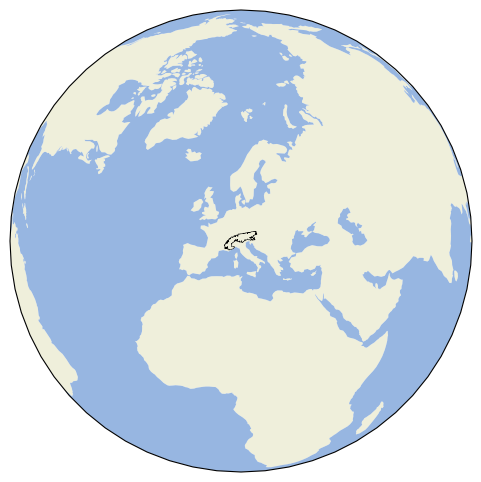

In [4]:
xmin, ymin, xmax, ymax = alps_gdf.total_bounds

fig = plt.figure(figsize=(6,6))
central_longitude = (xmin + xmax) / 2
central_latitude = (ymin + ymax) / 2
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude))
#ax.set_extent([-180, -100, 50, 80], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, zorder=0)
ax.add_feature(cfeature.OCEAN, zorder=0)
#ax.add_feature(cfeature.COASTLINE, zorder=1)
#ax.add_feature(cfeature.BORDERS, zorder=1)
#ax.add_feature(cfeature.LAKES, zorder=1)
#ax.add_feature(cfeature.RIVERS, zorder=1)
ax.add_geometries(alps_gdf.geometry, crs=ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=0.3, zorder=2)
from shapely.geometry import box
bbox = box(xmin-1E5, ymin-1E5, xmax+1E5, ymax+1E5)


fig.savefig('figures/orthographic_context_map.png', dpi=300, transparent=True)

In [5]:
alps_hillshade_da = rioxarray.open_rasterio('../../data/global_hillshade_robinson.tif', masked=True, chunks='auto').rio.clip_box(*alps_utm_gdf.buffer(50000).total_bounds,crs=alps_utm_gdf.crs).squeeze().rio.reproject(alps_utm_gdf.crs, resampling=rasterio.enums.Resampling.bilinear)
alps_hillshade_da

<xarray.DataArray (y: 722, x: 1108)> Size: 3MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(722, 1108), dtype=float32)
Coordinates:
  * x            (x) float64 9kB 6.283e+04 6.38e+04 ... 1.136e+06 1.137e+06
  * y            (y) float64 6kB 5.44e+06 5.439e+06 ... 4.742e+06 4.741e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_SOFTWARE:        Adobe Photoshop CS5 Macintosh
    TIFFTAG_DATETIME:        2012:07:20 09:39:49
    TIFFTAG_XRESOLUTION:     72
    TIFFTAG_YRESOLUTION:     72
    TIFFTAG_RESOLUTIONUNIT:  2 (pixels/inch)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0
    _FillValue:              nan

In [6]:
global_ds = xr.open_zarr(config.global_runoff_store, 
                         consolidated=True, 
                         decode_coords='all',
                         )
global_ds

<xarray.Dataset> Size: 14TB
Dimensions:                     (latitude: 195970, longitude: 499998,
                                 water_year: 10)
Coordinates:
  * latitude                    (latitude) float64 2MB 81.1 81.1 ... -60.0 -60.0
  * longitude                   (longitude) float64 4MB -180.0 -180.0 ... 180.0
    spatial_ref                 int32 4B ...
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 4TB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float64 784GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 392GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float64 8TB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float64 784GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes:
    processed_tiles:  []

In [7]:
alps_utm_ds = global_ds[['runoff_onset_median','runoff_onset']].rio.clip_box(*alps_utm_gdf.buffer(5000).total_bounds,crs=alps_utm_gdf.crs).coarsen(latitude=3, longitude=3,boundary='trim').mean().compute().rio.reproject(alps_utm_gdf.crs)
alps_utm_ds

<xarray.Dataset> Size: 810MB
Dimensions:              (x: 5529, y: 3329, water_year: 10)
Coordinates:
  * x                    (x) float64 44kB 1.297e+05 1.299e+05 ... 1.126e+06
  * y                    (y) float64 27kB 5.39e+06 5.389e+06 ... 4.79e+06
    spatial_ref          int64 8B 0
  * water_year           (water_year) int64 80B 2015 2016 2017 ... 2023 2024
Data variables:
    runoff_onset_median  (y, x) float32 74MB nan nan nan nan ... nan nan nan nan
    runoff_onset         (water_year, y, x) float32 736MB nan nan ... nan nan
Attributes:
    processed_tiles:  []

In [8]:
alps_utm_ds['runoff_onset_anomaly'] = alps_utm_ds['runoff_onset'] - alps_utm_ds['runoff_onset_median']
alps_utm_ds

<xarray.Dataset> Size: 2GB
Dimensions:               (x: 5529, y: 3329, water_year: 10)
Coordinates:
  * x                     (x) float64 44kB 1.297e+05 1.299e+05 ... 1.126e+06
  * y                     (y) float64 27kB 5.39e+06 5.389e+06 ... 4.79e+06
    spatial_ref           int64 8B 0
  * water_year            (water_year) int64 80B 2015 2016 2017 ... 2023 2024
Data variables:
    runoff_onset_median   (y, x) float32 74MB nan nan nan nan ... nan nan nan
    runoff_onset          (water_year, y, x) float32 736MB nan nan ... nan nan
    runoff_onset_anomaly  (water_year, y, x) float32 736MB nan nan ... nan nan
Attributes:
    processed_tiles:  []

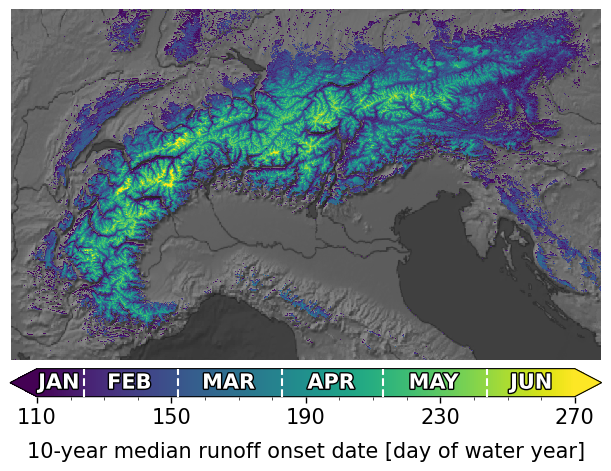

In [9]:
fig = plt.figure(figsize=(6, 4.6), layout='constrained')
gs = GridSpec(2, 1, figure=fig, height_ratios=[1, 0.08], hspace=0.00)

ax = fig.add_subplot(gs[0])
cax = fig.add_subplot(gs[1])

alps_hillshade_da.plot.imshow(cmap='grey', ax=ax, vmin=0, vmax=400, add_colorbar=False, zorder=0)

dowy_start = 110
dowy_end = 270
alps_utm_ds['runoff_onset_median'].plot.imshow(vmin=dowy_start, vmax=dowy_end, ax=ax, add_colorbar=False)
create_month_colorbar(dowy_start, dowy_end, hemisphere="northern", ax=cax)

ax.set_aspect('equal')
ax.set_title("")
ax.axis('off')

ax.set_xlim([alps_utm_gdf.total_bounds[0], alps_utm_gdf.total_bounds[2]])
ax.set_ylim([alps_utm_gdf.total_bounds[1], alps_utm_gdf.total_bounds[3]])

fig.savefig('figures/median_runoff_onset_map.png', dpi=300, bbox_inches='tight')

Saved runoff onset anomaly horizontal colorbar as png


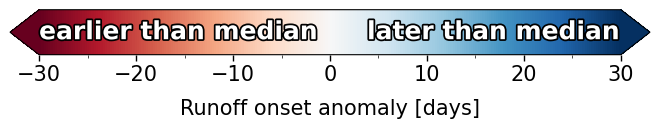

In [10]:
figcbar = create_diverging_colorbar(
    vmin=-30, vmax=30, cmap='RdBu',
    label='Runoff onset anomaly [days]',
    ticks=[-30, -20, -10, 0, 10, 20, 30],
    minor_tick_spacing=5,
    left_text='earlier than median',
    right_text='later than median',
)

figcbar.savefig(f"figures/runoff_onset_anomaly_colorbar_horizontal.png",
            bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
print('Saved runoff onset anomaly horizontal colorbar as png')

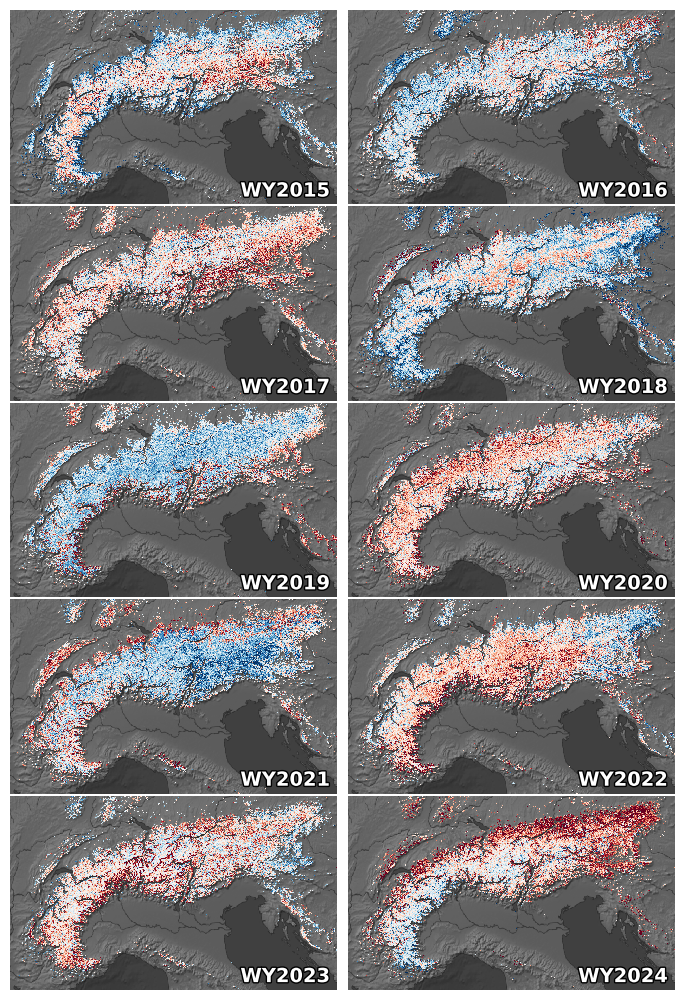

In [11]:
f,axs=plt.subplots(5,2,figsize=(7.0,10))

for wy, ax in zip(alps_utm_ds['water_year'].values,axs.flat):
    alps_hillshade_da.plot.imshow(cmap='grey',ax=ax,vmin=0,vmax=400,add_colorbar=False,zorder=0)        
    alps_utm_ds['runoff_onset_anomaly'].sel(water_year=wy).plot.imshow(cmap='RdBu',ax=ax,vmin=-30,vmax=30,add_colorbar=False)
    ax.set_title("")
    ax.text(
        0.98, 0.02, f'WY{wy}',
        transform=ax.transAxes,
        ha='right', va='bottom',
        color='white', fontweight='bold', fontsize=14,
        path_effects=[path_effects.withStroke(linewidth=2, foreground='black')]
    )
    #alps_gdf.boundary.plot(color='black',ax=ax)#,transform=cartopy_crs)
    ax.axis('off')
    ax.set_xlim([alps_utm_gdf.total_bounds[0],alps_utm_gdf.total_bounds[2]])
    ax.set_ylim([alps_utm_gdf.total_bounds[1],alps_utm_gdf.total_bounds[3]])
    ax.set_aspect('equal')

f.subplots_adjust(wspace=-0.03,hspace=0.01, left=0.01, right=0.99, top=0.99,bottom=0.01, )
f.savefig('figures/anomaly_maps_52grid_no_cbar.png', dpi=300)

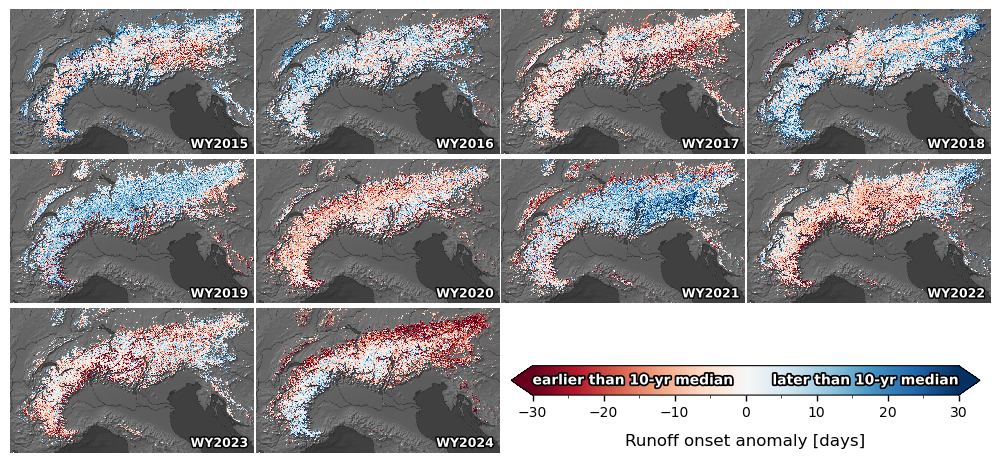

In [12]:
fig = plt.figure(figsize=(10, 4.6))
gs = GridSpec(3, 4, figure=fig, hspace=0.015, wspace=0.01,
              left=0.01, right=0.99, top=0.99, bottom=0.02)

water_years = alps_utm_ds['water_year'].values

# Only create the 10 map axes — do NOT touch gs[2,2] or gs[2,3] yet
positions = [(r, c) for r in range(3) for c in range(4)][:10]
axs = [fig.add_subplot(gs[r, c]) for r, c in positions]

for wy, ax in zip(water_years, axs):
    alps_hillshade_da.plot.imshow(cmap='grey', ax=ax, vmin=0, vmax=400, add_colorbar=False, zorder=0)
    alps_utm_ds['runoff_onset_anomaly'].sel(water_year=wy).plot.imshow(cmap='RdBu', ax=ax, vmin=-30, vmax=30, add_colorbar=False)
    ax.set_title('')
    ax.text(0.98, 0.02, f'WY{wy}', transform=ax.transAxes,
            ha='right', va='bottom', color='white', fontweight='bold', fontsize=9,
            path_effects=[path_effects.withStroke(linewidth=2, foreground='black')])
    ax.axis('off')
    ax.set_xlim([alps_utm_gdf.total_bounds[0], alps_utm_gdf.total_bounds[2]])
    ax.set_ylim([alps_utm_gdf.total_bounds[1], alps_utm_gdf.total_bounds[3]])
    ax.set_aspect('equal')

# Spanning subplot covers both empty slots cleanly
cax_ref = fig.add_subplot(gs[2, 2:4])
cax_ref.axis('off')
pos = cax_ref.get_position()
cax = fig.add_axes([pos.x0 + 0.01, pos.y0 + 0.40 * pos.height,
                    pos.width - 0.02, 0.20 * pos.height])

create_diverging_colorbar(
    vmin=-30, vmax=30, cmap='RdBu', ax=cax,
    label='Runoff onset anomaly [days]',
    ticks=[-30, -20, -10, 0, 10, 20, 30],
    minor_tick_spacing=5,
    left_text='earlier than 10-yr median',
    right_text='later than 10-yr median',
    label_fontsize=12, tick_labelsize=10, text_fontsize=10,
)

fig.savefig('figures/anomaly_maps_34grid_w_cbar.png', dpi=300)